In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [2]:
import os

print(os.getcwd())

C:\Users\Suthishna kumar\Downloads\WEEK 13\Notebooks


In [3]:
telco_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
tickets_path ="customer_support_tickets.csv"

telco_df = pd.read_csv(telco_path)
tickets_df = pd.read_csv(tickets_path)

print("Telco dataset loaded:", telco_df.shape)
print("Tickets dataset loaded:", tickets_df.shape)

Telco dataset loaded: (7043, 21)
Tickets dataset loaded: (8469, 17)


In [4]:
#Missing values
missing_values = telco_df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [5]:
print("Number of duplicate rows:", telco_df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
print(telco_df["TotalCharges"].dtype)

object


In [7]:
telco_df["TotalCharges"] = pd.to_numeric(
    telco_df["TotalCharges"],
    errors="coerce"
)


In [8]:
print("Missing TotalCharges:", telco_df["TotalCharges"].isnull().sum())

Missing TotalCharges: 11


In [9]:
telco_df[telco_df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


## Analyse & Visulization

In [10]:
print(telco_df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
print(
    telco_df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


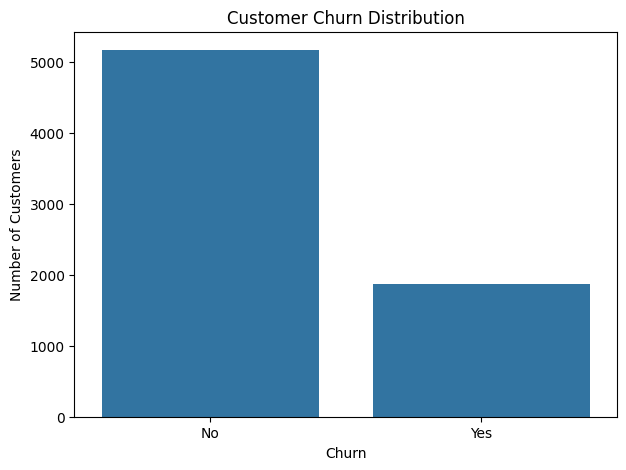

In [12]:
#Churn distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=telco_df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

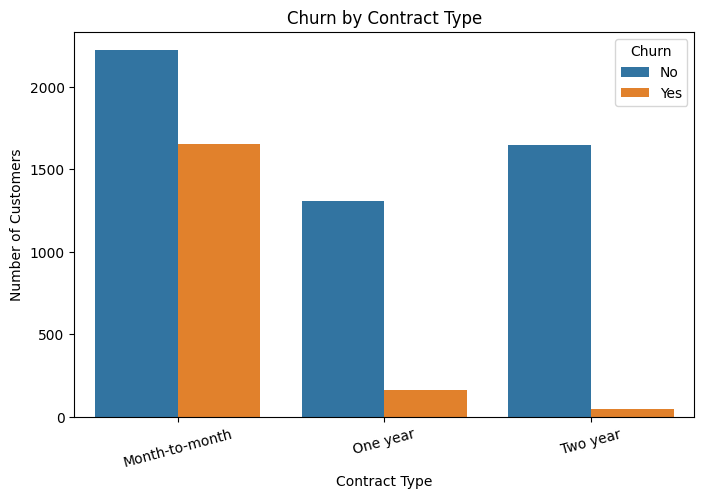

In [13]:
#Churn by contract
plt.figure(figsize=(8, 5))

sns.countplot(
    data=telco_df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.show()

In [14]:
contract_churn = pd.crosstab(
    telco_df["Contract"],
    telco_df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


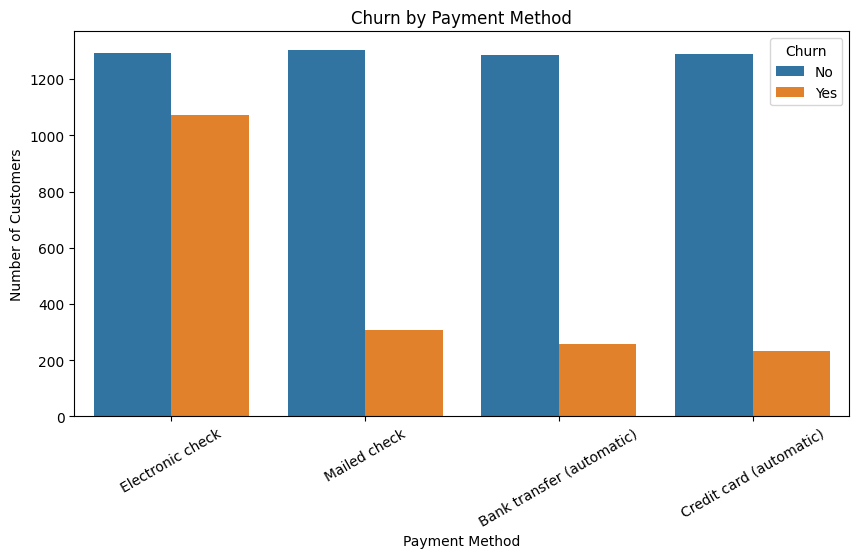

In [15]:
#Payment method
plt.figure(figsize=(10, 5))

sns.countplot(
    data=telco_df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.show()

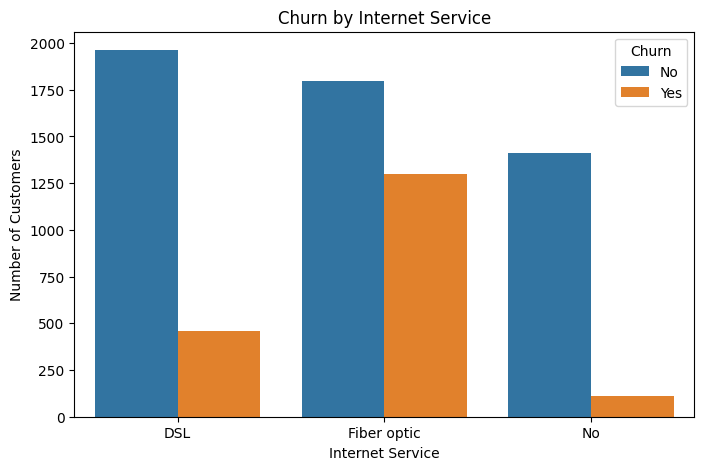

In [16]:
#Internet service
plt.figure(figsize=(8, 5))

sns.countplot(
    data=telco_df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

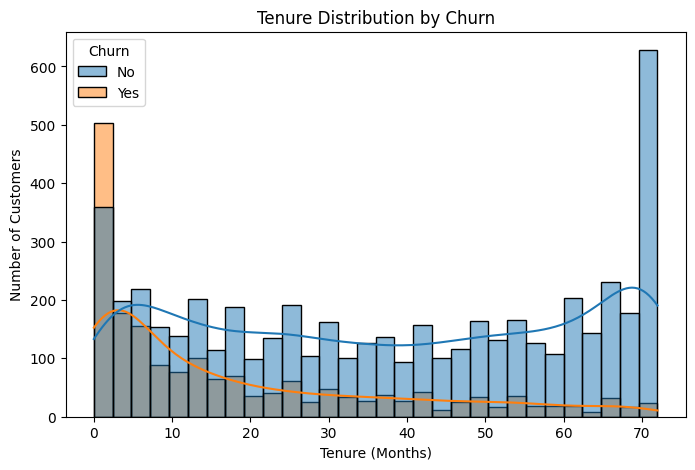

In [17]:
#Tenure
plt.figure(figsize=(8, 5))

sns.histplot(
    data=telco_df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

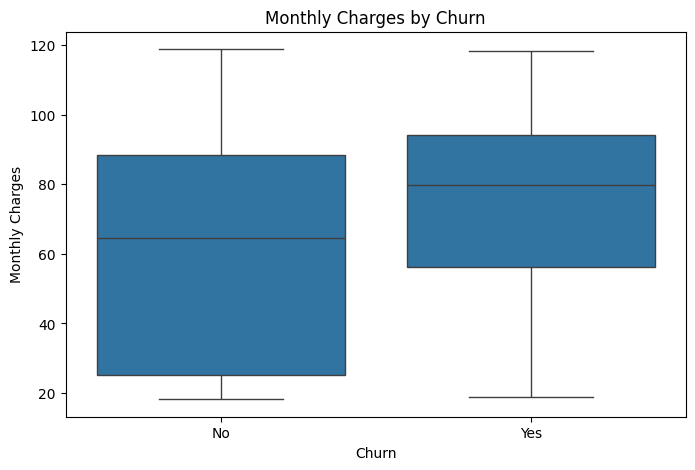

In [18]:
#Monthly charges
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco_df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [19]:
# Numerical columns
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

telco_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


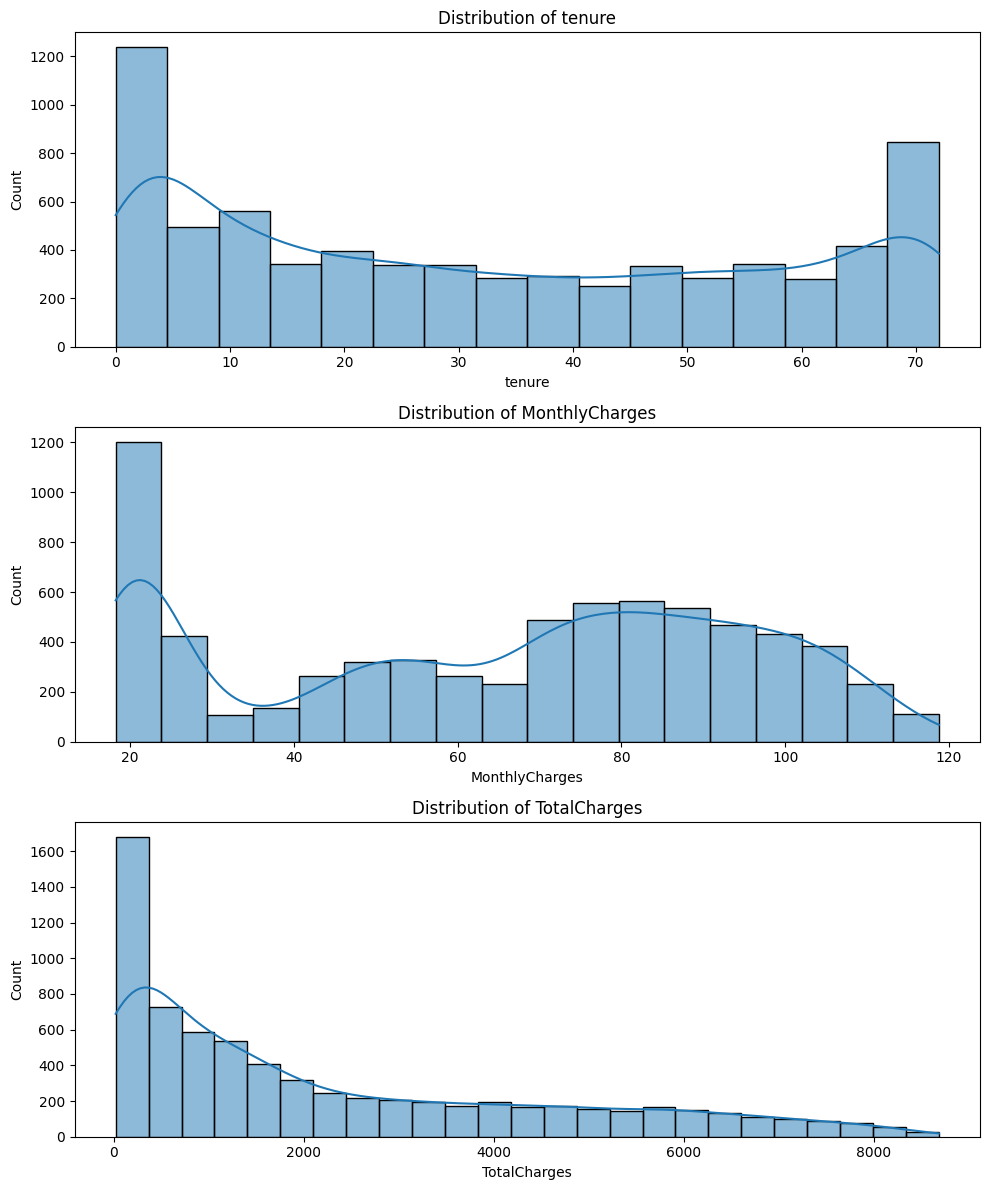

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for ax, column in zip(axes, numerical_columns):
    sns.histplot(
        data=telco_df,
        x=column,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

In [21]:
#Correlation analysis
correlation = telco_df[numerical_columns].corr()

correlation

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


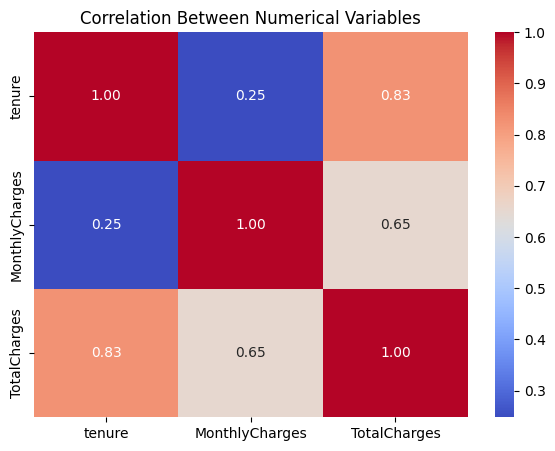

In [22]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.show()

In [23]:
#Churn rate by tenure groups
telco_df["TenureGroup"] = pd.cut(
    telco_df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

tenure_churn = pd.crosstab(
    telco_df["TenureGroup"],
    telco_df["Churn"],
    normalize="index"
) * 100

tenure_churn.round(2)

Churn,No,Yes
TenureGroup,,
0-6 Months,47.06,52.94
7-12 Months,64.11,35.89
13-24 Months,71.29,28.71
25-48 Months,79.61,20.39
49-72 Months,90.49,9.51


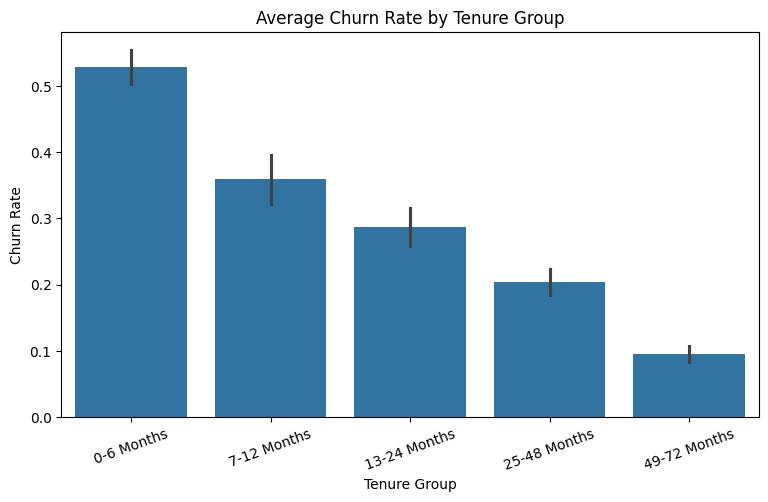

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=telco_df,
    x="TenureGroup",
    y=telco_df["Churn"].eq("Yes").astype(int)
)

plt.title("Average Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")

plt.xticks(rotation=20)
plt.show()

In [25]:
#Churn rate by monthly-charge group
telco_df["MonthlyChargeGroup"] = pd.cut(
    telco_df["MonthlyCharges"],
    bins=[0, 30, 60, 90, 120],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

monthly_churn = pd.crosstab(
    telco_df["MonthlyChargeGroup"],
    telco_df["Churn"],
    normalize="index"
) * 100

monthly_churn.round(2)

Churn,No,Yes
MonthlyChargeGroup,,
Low,90.20,9.80
Medium,74.07,25.93
High,66.09,33.91
Very High,67.22,32.78


In [26]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [27]:
service_yes = telco_df[service_columns].apply(
    lambda col: col.eq("Yes")
)

telco_df["NumberOfServices"] = service_yes.sum(axis=1)

telco_df["NumberOfServices"].value_counts().sort_index()

NumberOfServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

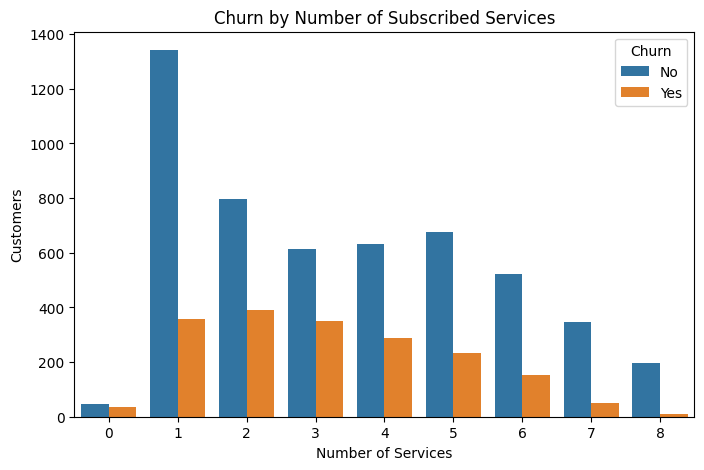

In [28]:
#Visualize:

plt.figure(figsize=(8, 5))

sns.countplot(
    data=telco_df,
    x="NumberOfServices",
    hue="Churn"
)

plt.title("Churn by Number of Subscribed Services")
plt.xlabel("Number of Services")
plt.ylabel("Customers")

plt.show()

In [29]:
#High-value customers
monthly_threshold = telco_df["MonthlyCharges"].quantile(0.75)

telco_df["HighValueCustomer"] = (
    telco_df["MonthlyCharges"] >= monthly_threshold
)

print("High-value threshold:", round(monthly_threshold, 2))

High-value threshold: 89.85


In [30]:
pd.crosstab(
    telco_df["HighValueCustomer"],
    telco_df["Churn"],
    normalize="index"
).round(3) * 100

Churn,No,Yes
HighValueCustomer,,
False,75.6,24.4
True,67.3,32.7


In [32]:
#Quick customer segments


def customer_segment(row):
    if row["tenure"] <= 6 and row["MonthlyCharges"] >= monthly_threshold:
        return "New High-Value"
    
    elif row["tenure"] >= 48 and row["MonthlyCharges"] >= monthly_threshold:
        return "Loyal High-Value"
    
    elif row["tenure"] <= 6:
        return "New Customer"
    
    elif row["tenure"] >= 48:
        return "Long-Term Customer"
    
    else:
        return "Regular Customer"


telco_df["CustomerSegment"] = telco_df.apply(
    customer_segment,
    axis=1
)

telco_df["CustomerSegment"].value_counts()

CustomerSegment
Regular Customer      3259
Long-Term Customer    1375
New Customer          1359
Loyal High-Value       928
New High-Value         122
Name: count, dtype: int64

In [33]:
segment_churn = pd.crosstab(
    telco_df["CustomerSegment"],
    telco_df["Churn"],
    normalize="index"
) * 100

segment_churn.round(2)

Churn,No,Yes
CustomerSegment,,
Long-Term Customer,95.35,4.65
Loyal High-Value,82.97,17.03
New Customer,49.15,50.85
New High-Value,23.77,76.23
Regular Customer,73.52,26.48


In [35]:
processed_path = "/processed"

os.makedirs(processed_path, exist_ok=True)

telco_df.to_csv(
    "processed/telco_eda_processed.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
